# Lecture 3: Kinematics and Dynamics

This notebook mirrors the order of `Lecture 3 Kinematics and dynamics.pptx`.
Each section stays close to the corresponding slides: equations in markdown where the deck presents equations,
and code only where it helps recreate the associated figures or symbolic calculations.

In [1]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.integrate import solve_ivp
from IPython.display import Math, display

SEED = 7
np.random.seed(SEED)

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 12


def set_equal_axes(ax, lim=1.2):
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.grid(True, alpha=0.2)


def draw_single_link(ax, theta, length=1.0, color="C0", label=None):
    endpoint = np.array([length * np.cos(theta), length * np.sin(theta)])
    ax.plot([0.0, endpoint[0]], [0.0, endpoint[1]], color=color, lw=3, marker="o", label=label)
    return endpoint


def forward_kinematics_2link(theta, lengths=(0.34, 0.46)):
    theta1, theta2 = theta
    l1, l2 = lengths
    elbow = np.array([l1 * np.cos(theta1), l1 * np.sin(theta1)])
    hand = elbow + np.array([l2 * np.cos(theta1 + theta2), l2 * np.sin(theta1 + theta2)])
    return elbow, hand


def draw_two_link(ax, theta, lengths=(0.34, 0.46), color="C0", alpha=1.0, lw=3, label=None):
    elbow, hand = forward_kinematics_2link(theta, lengths=lengths)
    ax.plot([0.0, elbow[0]], [0.0, elbow[1]], color=color, lw=lw, alpha=alpha)
    ax.plot([elbow[0], hand[0]], [elbow[1], hand[1]], color=color, lw=lw, alpha=alpha, label=label)
    ax.scatter([0.0, elbow[0], hand[0]], [0.0, elbow[1], hand[1]], color=color, s=20, alpha=alpha)
    return elbow, hand


def jacobian_2link(theta, lengths=(0.34, 0.46)):
    theta1, theta2 = theta
    l1, l2 = lengths
    return np.array(
        [
            [-l1 * np.sin(theta1) - l2 * np.sin(theta1 + theta2), -l2 * np.sin(theta1 + theta2)],
            [l1 * np.cos(theta1) + l2 * np.cos(theta1 + theta2), l2 * np.cos(theta1 + theta2)],
        ],
        dtype=float,
    )


def jdot_2link(theta, theta_dot, lengths=(0.34, 0.46)):
    theta1, theta2 = theta
    dtheta1, dtheta2 = theta_dot
    l1, l2 = lengths
    total_rate = dtheta1 + dtheta2
    return np.array(
        [
            [
                -l1 * np.cos(theta1) * dtheta1 - l2 * np.cos(theta1 + theta2) * total_rate,
                -l2 * np.cos(theta1 + theta2) * total_rate,
            ],
            [
                -l1 * np.sin(theta1) * dtheta1 - l2 * np.sin(theta1 + theta2) * total_rate,
                -l2 * np.sin(theta1 + theta2) * total_rate,
            ],
        ],
        dtype=float,
    )


def inverse_kinematics_2link(target, lengths=(0.34, 0.46), elbow="up"):
    x, y = target
    l1, l2 = lengths
    c2 = (x**2 + y**2 - l1**2 - l2**2) / (2.0 * l1 * l2)
    if np.abs(c2) > 1.0:
        raise ValueError("Target lies outside the reachable workspace.")
    s2 = np.sqrt(np.maximum(0.0, 1.0 - c2**2))
    if elbow == "down":
        s2 = -s2
    theta2 = np.arctan2(s2, c2)
    theta1 = np.arctan2(y, x) - np.arctan2(l2 * s2, l1 + l2 * c2)
    return np.array([theta1, theta2], dtype=float)


def forward_kinematics_3link(theta, lengths=(0.35, 0.30, 0.20)):
    q1, q2, q3 = theta
    l1, l2, l3 = lengths
    p1 = np.array([l1 * np.cos(q1), l1 * np.sin(q1)])
    p2 = p1 + np.array([l2 * np.cos(q1 + q2), l2 * np.sin(q1 + q2)])
    p3 = p2 + np.array([l3 * np.cos(q1 + q2 + q3), l3 * np.sin(q1 + q2 + q3)])
    return p1, p2, p3


def redundant_solutions_3link(target, lengths=(0.35, 0.30, 0.20)):
    l1, l2, l3 = lengths
    phi_values = np.linspace(-np.pi, np.pi, 19)
    solutions = {}
    for phi in phi_values:
        wrist = target - l3 * np.array([np.cos(phi), np.sin(phi)])
        for elbow in ("up", "down"):
            try:
                q1, q2 = inverse_kinematics_2link(wrist, lengths=(l1, l2), elbow=elbow)
            except ValueError:
                continue
            q3 = phi - q1 - q2
            key = tuple(np.round([q1, q2, q3], 4))
            solutions[key] = np.array([q1, q2, q3])
    return list(solutions.values())

## Slides 3-7: Kinematics versus dynamics

Kinematics answers questions about **where the arm is going**:

$$
\text{position}, \quad \text{velocity}, \quad \text{acceleration}
$$

Dynamics answers questions about **why the arm moves**:

$$
\text{force}, \quad \text{torque}, \quad \text{mass}, \quad \text{inertia}
$$

The lecture starts with the simplest useful model: a rigid link attached to a joint.

## Slides 8-13: Forward kinematics for a single-link arm

For one rigid link of length $l$ with joint angle $\theta$, the hand position is

$$
\mathbf{h}(\theta) =
\begin{bmatrix}
l \cos \theta \\
l \sin \theta
\end{bmatrix}.
$$

This is the basic "position the joints, then find the hand" calculation in the slides.

In [2]:
theta_sym, theta_dot_sym, theta_ddot_sym, l_sym = sp.symbols("theta theta_dot theta_ddot l", real=True)

h_sym = sp.Matrix([l_sym * sp.cos(theta_sym), l_sym * sp.sin(theta_sym)])
J_sym = h_sym.jacobian([theta_sym])
Jdot_sym = sp.diff(J_sym, theta_sym) * theta_dot_sym
hddot_sym = sp.simplify(J_sym * sp.Matrix([theta_ddot_sym]) + Jdot_sym * sp.Matrix([theta_dot_sym]))

display(Math(r"\mathbf{h}(\theta) = " + sp.latex(h_sym)))
display(Math(r"J(\theta) = \frac{\partial \mathbf{h}}{\partial \theta} = " + sp.latex(J_sym)))
display(Math(r"\dot{J}(\theta, \dot{\theta}) = " + sp.latex(Jdot_sym)))
display(Math(r"\ddot{\mathbf{h}} = J(\theta)\ddot{\theta} + \dot{J}(\theta, \dot{\theta})\dot{\theta} = " + sp.latex(hddot_sym)))

hand_position_1d = sp.lambdify((theta_sym, l_sym), h_sym, "numpy")
jacobian_1d = sp.lambdify((theta_sym, l_sym), J_sym, "numpy")
jdot_1d = sp.lambdify((theta_sym, theta_dot_sym, l_sym), Jdot_sym, "numpy")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

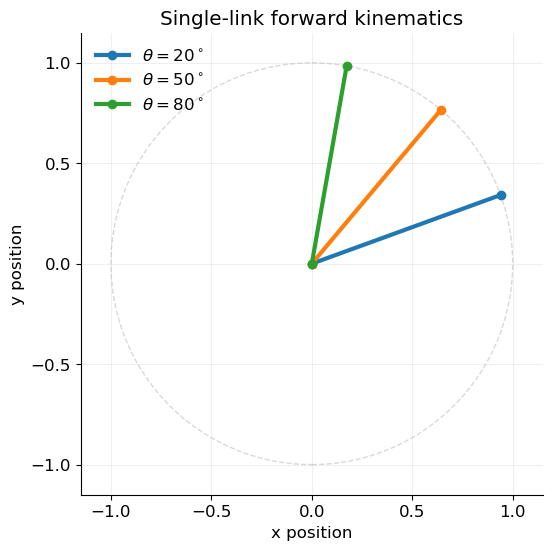

In [3]:
length = 1.0
angles = np.deg2rad([20, 50, 80])
colors = ["C0", "C1", "C2"]

fig, ax = plt.subplots(figsize=(6, 6))
circle = plt.Circle((0.0, 0.0), length, color="0.85", fill=False, linestyle="--")
ax.add_patch(circle)

for angle, color in zip(angles, colors):
    draw_single_link(ax, angle, length=length, color=color, label=fr"$\theta={np.rad2deg(angle):.0f}^\circ$")

set_equal_axes(ax, lim=1.15)
ax.set_title("Single-link forward kinematics")
ax.set_xlabel("x position")
ax.set_ylabel("y position")
ax.legend(frameon=False)
plt.show()

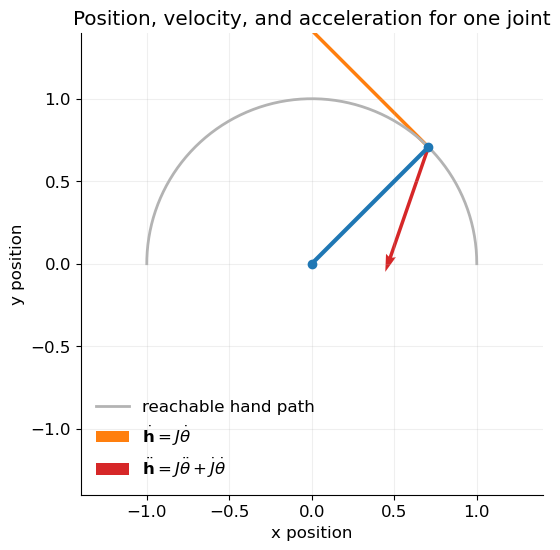

In [4]:
theta_path = np.deg2rad(np.linspace(0.0, 180.0, 300))
hand_path = np.column_stack(
    [
        length * np.cos(theta_path),
        length * np.sin(theta_path),
    ]
)

sample_theta = np.deg2rad(45.0)
sample_theta_dot = 1.2
sample_theta_ddot = -0.7

sample_position = np.asarray(hand_position_1d(sample_theta, length), dtype=float).reshape(2)
sample_velocity = np.asarray(jacobian_1d(sample_theta, length), dtype=float).reshape(2) * sample_theta_dot
sample_jdot = np.asarray(jdot_1d(sample_theta, sample_theta_dot, length), dtype=float).reshape(2)
sample_acceleration = (
    np.asarray(jacobian_1d(sample_theta, length), dtype=float).reshape(2) * sample_theta_ddot
    + sample_jdot * sample_theta_dot
)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(hand_path[:, 0], hand_path[:, 1], color="0.7", lw=2, label="reachable hand path")
draw_single_link(ax, sample_theta, length=length, color="C0")
ax.quiver(
    sample_position[0],
    sample_position[1],
    sample_velocity[0],
    sample_velocity[1],
    angles="xy",
    scale_units="xy",
    scale=1.0,
    color="C1",
    label=r"$\dot{\mathbf{h}} = J \dot{\theta}$",
)
ax.quiver(
    sample_position[0],
    sample_position[1],
    sample_acceleration[0],
    sample_acceleration[1],
    angles="xy",
    scale_units="xy",
    scale=2.0,
    color="C3",
    label=r"$\ddot{\mathbf{h}} = J \ddot{\theta} + \dot{J}\dot{\theta}$",
)
set_equal_axes(ax, lim=1.4)
ax.set_title("Position, velocity, and acceleration for one joint")
ax.set_xlabel("x position")
ax.set_ylabel("y position")
ax.legend(frameon=False, loc="lower left")
plt.show()

## Slides 14-21: The Jacobian makes velocity and acceleration compact

The Jacobian is the derivative of hand position with respect to joint angle:

$$
J(\theta) = \frac{\partial \mathbf{h}}{\partial \theta}.
$$

For a single-link arm, $J$ is a $2 \times 1$ matrix. It maps angular velocity into Cartesian velocity:

$$
\dot{\mathbf{h}} = J(\theta)\dot{\theta}.
$$

Acceleration needs one extra term because the Jacobian changes with angle:

$$
\ddot{\mathbf{h}} = J(\theta)\ddot{\theta} + \dot{J}(\theta, \dot{\theta})\dot{\theta}.
$$

This is the same pattern we will use again for the two-link arm.

## Slides 22-26: Inverse kinematics for one link

If the hand stays on the circle of radius $l$, the joint angle is just

$$
\theta = \operatorname{atan2}(y, x).
$$

For inverse velocity we use the pseudo-inverse:

$$
\dot{\theta} = J^+ \dot{\mathbf{h}}.
$$

This only works for hand velocities that are actually reachable by the arm. A single rigid link can move the hand
tangentially around the circle, but not radially inward or outward.

In [5]:
def inverse_position_1d(target, length=1.0):
    x, y = target
    radius = np.hypot(x, y)
    if not np.isclose(radius, length, atol=1e-6):
        raise ValueError("The target must lie on the reachable circle for a single rigid link.")
    return float(np.arctan2(y, x))


target = np.array([np.cos(np.deg2rad(65.0)), np.sin(np.deg2rad(65.0))])
theta_est = inverse_position_1d(target, length=1.0)
reconstructed = np.asarray(hand_position_1d(theta_est, 1.0), dtype=float).reshape(2)

print(f"Target hand position: {target.round(3)}")
print(f"Recovered joint angle: {np.rad2deg(theta_est):.2f} deg")
print(f"Forward kinematics at recovered angle: {reconstructed.round(3)}")

Target hand position: [0.423 0.906]
Recovered joint angle: 65.00 deg
Forward kinematics at recovered angle: [0.423 0.906]


In [6]:
theta_example = np.deg2rad(55.0)
J_example = np.asarray(jacobian_1d(theta_example, 1.0), dtype=float)
J_pinv = np.linalg.pinv(J_example)

desired_tangent = 0.7 * np.array([-np.sin(theta_example), np.cos(theta_example)])
desired_radial = 0.7 * np.array([np.cos(theta_example), np.sin(theta_example)])

for label, desired in [
    ("reachable tangential velocity", desired_tangent),
    ("unreachable radial velocity", desired_radial),
]:
    theta_dot_est = float((J_pinv @ desired).squeeze())
    realized = (J_example * theta_dot_est).reshape(2)
    error = np.linalg.norm(desired - realized)
    print(label)
    print(f"  desired hand velocity : {desired.round(3)}")
    print(f"  estimated theta_dot   : {theta_dot_est:.3f} rad/s")
    print(f"  realized hand velocity: {realized.round(3)}")
    print(f"  mismatch norm         : {error:.3f}")

reachable tangential velocity
  desired hand velocity : [-0.573  0.402]
  estimated theta_dot   : 0.700 rad/s
  realized hand velocity: [-0.573  0.402]
  mismatch norm         : 0.000
unreachable radial velocity
  desired hand velocity : [0.402 0.573]
  estimated theta_dot   : -0.000 rad/s
  realized hand velocity: [ 0. -0.]
  mismatch norm         : 0.700


## Slides 27-32: Two-link arm kinematics in 2D

For a shoulder angle $\theta_1$ and elbow angle $\theta_2$:

$$
x = l_1 \cos \theta_1 + l_2 \cos(\theta_1 + \theta_2)
$$

$$
y = l_1 \sin \theta_1 + l_2 \sin(\theta_1 + \theta_2)
$$

The Jacobian becomes

$$
J(\theta_1, \theta_2) =
\begin{bmatrix}
-l_1 \sin \theta_1 - l_2 \sin(\theta_1 + \theta_2) & -l_2 \sin(\theta_1 + \theta_2) \\
 l_1 \cos \theta_1 + l_2 \cos(\theta_1 + \theta_2) &  l_2 \cos(\theta_1 + \theta_2)
\end{bmatrix}.
$$

In [7]:
q1_sym, q2_sym, dq1_sym, dq2_sym = sp.symbols("q1 q2 dq1 dq2", real=True)
l1_sym, l2_sym = sp.symbols("l1 l2", positive=True)

h2_sym = sp.Matrix(
    [
        l1_sym * sp.cos(q1_sym) + l2_sym * sp.cos(q1_sym + q2_sym),
        l1_sym * sp.sin(q1_sym) + l2_sym * sp.sin(q1_sym + q2_sym),
    ]
)
J2_sym = sp.simplify(h2_sym.jacobian([q1_sym, q2_sym]))
J2dot_sym = sp.simplify(sp.diff(J2_sym, q1_sym) * dq1_sym + sp.diff(J2_sym, q2_sym) * dq2_sym)

display(Math(r"\mathbf{h}(\theta_1, \theta_2) = " + sp.latex(h2_sym)))
display(Math(r"J(\theta_1, \theta_2) = " + sp.latex(J2_sym)))
display(Math(r"\dot{J}(\theta_1, \theta_2, \dot{\theta}_1, \dot{\theta}_2) = " + sp.latex(J2dot_sym)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

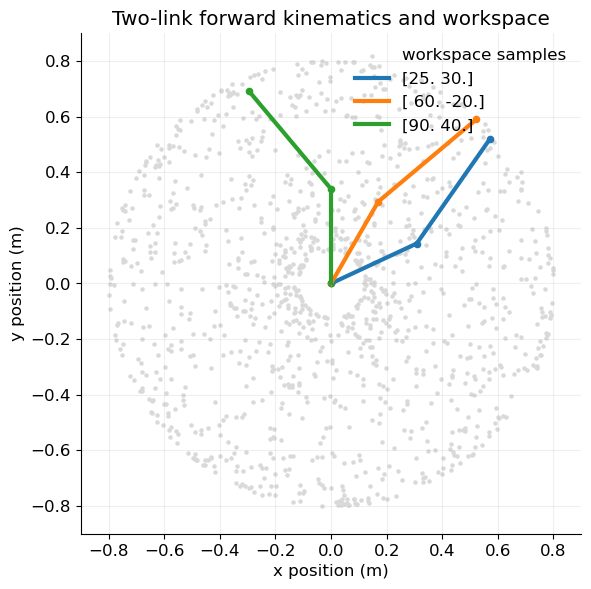

In [8]:
lengths = (0.34, 0.46)
configs = [
    np.deg2rad([25.0, 30.0]),
    np.deg2rad([60.0, -20.0]),
    np.deg2rad([90.0, 40.0]),
]

fig, ax = plt.subplots(figsize=(6.5, 6.5))
samples = np.random.uniform(-np.pi, np.pi, size=(1200, 2))
hands = np.array([forward_kinematics_2link(theta, lengths=lengths)[1] for theta in samples])
ax.scatter(hands[:, 0], hands[:, 1], s=5, color="0.85", label="workspace samples")

for theta, color in zip(configs, ["C0", "C1", "C2"]):
    draw_two_link(ax, theta, lengths=lengths, color=color, label=np.array2string(np.rad2deg(theta), precision=0))

set_equal_axes(ax, lim=0.9)
ax.set_title("Two-link forward kinematics and workspace")
ax.set_xlabel("x position (m)")
ax.set_ylabel("y position (m)")
ax.legend(frameon=False, loc="upper right")
plt.show()

### Inverse kinematics by the cosine rule

The slides solve the position inverse problem geometrically. For a target $(x, y)$ we first compute

$$
\cos \theta_2 = \frac{x^2 + y^2 - l_1^2 - l_2^2}{2 l_1 l_2},
$$

then recover the elbow angle and finally the shoulder angle:

$$
\theta_2 = \operatorname{atan2}(\pm \sqrt{1 - \cos^2 \theta_2}, \cos \theta_2)
$$

$$
\theta_1 = \operatorname{atan2}(y, x) - \operatorname{atan2}(l_2 \sin \theta_2, l_1 + l_2 \cos \theta_2).
$$

The $\pm$ gives the familiar elbow-up and elbow-down solutions.

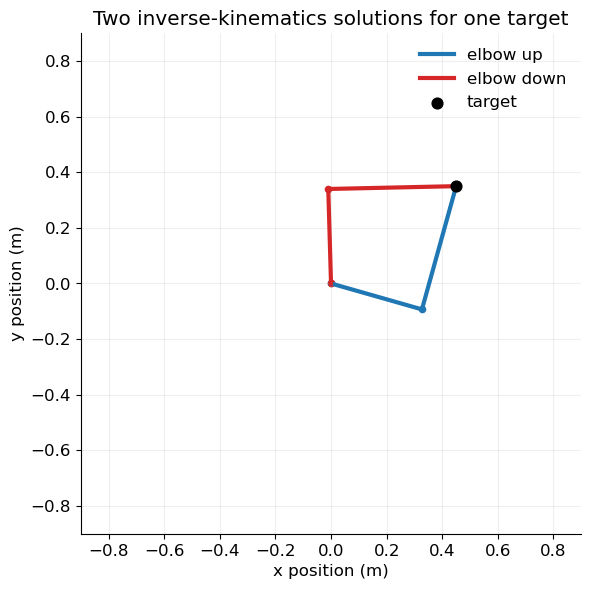

Elbow-up solution in deg : [-15.92  90.4 ]
Elbow-down solution in deg: [ 91.67 -90.4 ]


In [9]:
target = np.array([0.45, 0.35])
theta_up = inverse_kinematics_2link(target, lengths=lengths, elbow="up")
theta_down = inverse_kinematics_2link(target, lengths=lengths, elbow="down")

fig, ax = plt.subplots(figsize=(6.5, 6.5))
draw_two_link(ax, theta_up, lengths=lengths, color="C0", label="elbow up")
draw_two_link(ax, theta_down, lengths=lengths, color="C3", label="elbow down")
ax.scatter(target[0], target[1], color="black", s=60, zorder=5, label="target")
set_equal_axes(ax, lim=0.9)
ax.set_title("Two inverse-kinematics solutions for one target")
ax.set_xlabel("x position (m)")
ax.set_ylabel("y position (m)")
ax.legend(frameon=False)
plt.show()

print("Elbow-up solution in deg :", np.rad2deg(theta_up).round(2))
print("Elbow-down solution in deg:", np.rad2deg(theta_down).round(2))

In [10]:
theta_state = np.deg2rad([50.0, 30.0])
theta_dot_state = np.array([0.8, -0.5])
theta_ddot_state = np.array([0.4, 0.7])

J = jacobian_2link(theta_state, lengths=lengths)
Jdot = jdot_2link(theta_state, theta_dot_state, lengths=lengths)
hand_velocity = J @ theta_dot_state
hand_acceleration = J @ theta_ddot_state + Jdot @ theta_dot_state

theta_dot_recovered = np.linalg.solve(J, hand_velocity)
theta_ddot_recovered = np.linalg.solve(J, hand_acceleration - Jdot @ theta_dot_recovered)

print("Forward velocity:", hand_velocity.round(4))
print("Recovered joint velocity:", theta_dot_recovered.round(4))
print("Forward acceleration:", hand_acceleration.round(4))
print("Recovered joint acceleration:", theta_ddot_recovered.round(4))

Forward velocity: [-0.3443  0.1988]
Recovered joint velocity: [ 0.8 -0.5]
Forward acceleration: [-0.7496 -0.0322]
Recovered joint acceleration: [0.4 0.7]


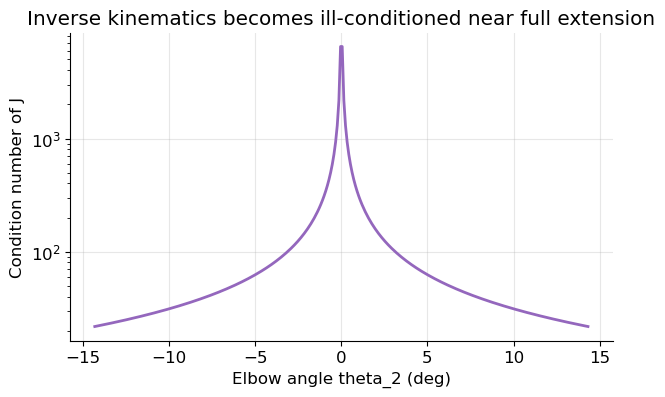

In [11]:
theta2_values = np.linspace(-0.25, 0.25, 300)
condition_numbers = [np.linalg.cond(jacobian_2link([0.4, theta2], lengths=lengths)) for theta2 in theta2_values]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.rad2deg(theta2_values), condition_numbers, color="C4", lw=2)
ax.set_yscale("log")
ax.set_xlabel("Elbow angle theta_2 (deg)")
ax.set_ylabel("Condition number of J")
ax.set_title("Inverse kinematics becomes ill-conditioned near full extension")
ax.grid(True, alpha=0.3)
plt.show()

## Slides 33-37: Redundant degrees of freedom

Once the arm has more joint angles than task dimensions, inverse kinematics is no longer unique.

A planar three-link arm still moves the hand in 2D, but now there are infinitely many postures that place the hand at the
same location. One easy way to see that is to treat the final hand orientation as a free variable: every orientation choice
gives a different wrist target, and therefore a different joint solution.

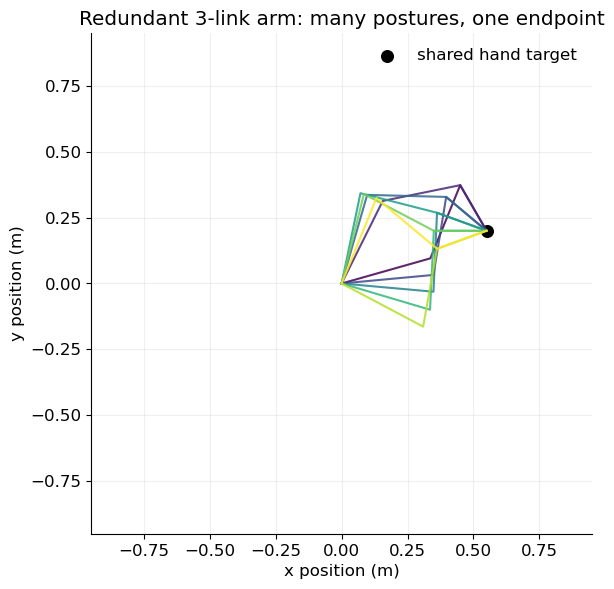

Number of distinct solutions found for this target: 18


In [12]:
target_redundant = np.array([0.55, 0.20])
redundant_lengths = (0.35, 0.30, 0.20)
solutions = redundant_solutions_3link(target_redundant, lengths=redundant_lengths)

fig, ax = plt.subplots(figsize=(7, 6.5))
for idx, solution in enumerate(solutions[:10]):
    p1, p2, p3 = forward_kinematics_3link(solution, lengths=redundant_lengths)
    color = plt.cm.viridis(idx / max(1, min(9, len(solutions) - 1)))
    ax.plot([0.0, p1[0], p2[0], p3[0]], [0.0, p1[1], p2[1], p3[1]], color=color, alpha=0.85)

ax.scatter(target_redundant[0], target_redundant[1], color="black", s=70, label="shared hand target")
set_equal_axes(ax, lim=0.95)
ax.set_title("Redundant 3-link arm: many postures, one endpoint")
ax.set_xlabel("x position (m)")
ax.set_ylabel("y position (m)")
ax.legend(frameon=False)
plt.show()

print(f"Number of distinct solutions found for this target: {len(solutions)}")

## Slides 38-47: Dynamics in 1D

For a single rigid link rotating about one joint, the Lagrangian is

$$
\mathcal{L}(\theta, \dot{\theta}) = T - U,
$$

with

$$
T = \frac{1}{2} I \dot{\theta}^2,
\qquad
U = m g r \sin \theta.
$$

Using the Euler-Lagrange equation

$$
\tau = \frac{d}{dt}\left(\frac{\partial \mathcal{L}}{\partial \dot{\theta}}\right) - \frac{\partial \mathcal{L}}{\partial \theta},
$$

we get

$$
\tau = I \ddot{\theta} + m g r \cos \theta,
$$

and therefore the forward dynamics are

$$
\ddot{\theta} = \frac{\tau - m g r \cos \theta}{I}.
$$

The coordinate convention here matches the kinematics above, where $\theta = 0$ points along the positive x-axis.

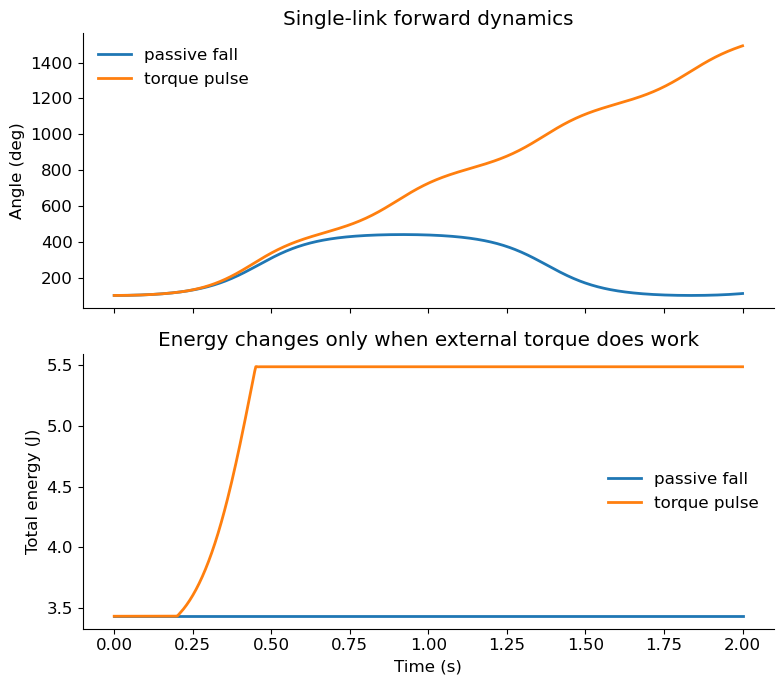

In [13]:
def single_link_dynamics(t, state, params, torque_fn):
    theta, dtheta = state
    tau = torque_fn(t, theta, dtheta)
    ddtheta = (tau - params["m"] * params["g"] * params["r"] * np.cos(theta)) / params["I"]
    return [dtheta, ddtheta]


def simulate_single_link(theta0, dtheta0, params, torque_fn, duration=2.0):
    t_eval = np.linspace(0.0, duration, 600)
    sol = solve_ivp(
        lambda t, y: single_link_dynamics(t, y, params, torque_fn),
        (0.0, duration),
        [theta0, dtheta0],
        t_eval=t_eval,
        max_step=0.01,
    )
    return sol


def zero_torque(t, theta, dtheta):
    return 0.0


def pulse_torque(t, theta, dtheta):
    return 0.7 if 0.2 <= t <= 0.45 else 0.0


single_params = {"m": 2.1, "r": 0.1692, "I": 0.05, "g": 9.81}
single_free = simulate_single_link(np.deg2rad(100.0), 0.0, single_params, zero_torque)
single_pulse = simulate_single_link(np.deg2rad(100.0), 0.0, single_params, pulse_torque)

def single_link_energy(solution, params):
    theta = solution.y[0]
    dtheta = solution.y[1]
    kinetic = 0.5 * params["I"] * dtheta**2
    potential = params["m"] * params["g"] * params["r"] * np.sin(theta)
    return kinetic, potential


fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)
axes[0].plot(single_free.t, np.rad2deg(single_free.y[0]), label="passive fall", lw=2)
axes[0].plot(single_pulse.t, np.rad2deg(single_pulse.y[0]), label="torque pulse", lw=2)
axes[0].set_ylabel("Angle (deg)")
axes[0].set_title("Single-link forward dynamics")
axes[0].legend(frameon=False)

for solution, label in [(single_free, "passive fall"), (single_pulse, "torque pulse")]:
    kinetic, potential = single_link_energy(solution, single_params)
    axes[1].plot(solution.t, kinetic + potential, lw=2, label=label)

axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Total energy (J)")
axes[1].set_title("Energy changes only when external torque does work")
axes[1].legend(frameon=False)
plt.tight_layout()
plt.show()

## Slides 48-59: Two-joint arm dynamics

This is the section with the strongest overlap with `HW2_Kinematics_Sensory_Integration.ipynb`.
The lecture sequence is:

1. Write the center-of-mass positions.
2. Compute kinetic and potential energy.
3. Apply the Euler-Lagrange equation.
4. Rewrite the result in matrix form.

For the standard two-link arm, the dynamics are usually written as

$$
M(\theta)\ddot{\theta} + C(\theta, \dot{\theta}) + G(\theta) = \tau.
$$

With

$$
\alpha = I_1 + I_2 + m_1 r_1^2 + m_2(l_1^2 + r_2^2),
\qquad
\beta = m_2 l_1 r_2,
\qquad
\delta = I_2 + m_2 r_2^2,
$$

the mass matrix becomes

$$
M(\theta) =
\begin{bmatrix}
\alpha + 2 \beta \cos \theta_2 & \delta + \beta \cos \theta_2 \\
\delta + \beta \cos \theta_2 & \delta
\end{bmatrix}.
$$

A common vector form for Coriolis and centrifugal terms is

$$
C(\theta, \dot{\theta}) =
\begin{bmatrix}
-\beta \sin \theta_2 (2 \dot{\theta}_1 \dot{\theta}_2 + \dot{\theta}_2^2) \\
\beta \sin \theta_2 \dot{\theta}_1^2
\end{bmatrix},
$$

and with the same coordinate convention as above the gravity term is

$$
G(\theta) =
\begin{bmatrix}
(m_1 r_1 + m_2 l_1) g \cos \theta_1 + m_2 r_2 g \cos(\theta_1 + \theta_2) \\
m_2 r_2 g \cos(\theta_1 + \theta_2)
\end{bmatrix}.
$$

In [14]:
m1_sym, m2_sym, r1_sym, r2_sym, I1_sym, I2_sym, g_sym = sp.symbols("m1 m2 r1 r2 I1 I2 g", positive=True)

p1_sym = sp.Matrix([r1_sym * sp.cos(q1_sym), r1_sym * sp.sin(q1_sym)])
p2_sym = sp.Matrix(
    [
        l1_sym * sp.cos(q1_sym) + r2_sym * sp.cos(q1_sym + q2_sym),
        l1_sym * sp.sin(q1_sym) + r2_sym * sp.sin(q1_sym + q2_sym),
    ]
)

qd_sym = sp.Matrix([dq1_sym, dq2_sym])
v1_sym = p1_sym.jacobian([q1_sym, q2_sym]) * qd_sym
v2_sym = p2_sym.jacobian([q1_sym, q2_sym]) * qd_sym

T_sym = sp.simplify(
    sp.Rational(1, 2) * m1_sym * (v1_sym.dot(v1_sym))
    + sp.Rational(1, 2) * I1_sym * dq1_sym**2
    + sp.Rational(1, 2) * m2_sym * (v2_sym.dot(v2_sym))
    + sp.Rational(1, 2) * I2_sym * (dq1_sym + dq2_sym) ** 2
)
U_sym = sp.simplify(m1_sym * g_sym * r1_sym * sp.sin(q1_sym) + m2_sym * g_sym * (l1_sym * sp.sin(q1_sym) + r2_sym * sp.sin(q1_sym + q2_sym)))
M_sym = sp.simplify(sp.hessian(T_sym, (dq1_sym, dq2_sym)))

display(Math(r"\mathbf{p}_1 = " + sp.latex(p1_sym)))
display(Math(r"\mathbf{p}_2 = " + sp.latex(p2_sym)))
display(Math(r"M(\theta) = " + sp.latex(M_sym)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [15]:
def two_link_matrices(theta, dtheta, params):
    theta1, theta2 = theta
    dtheta1, dtheta2 = dtheta

    alpha = (
        params["I1"]
        + params["I2"]
        + params["m1"] * params["r1"] ** 2
        + params["m2"] * (params["l1"] ** 2 + params["r2"] ** 2)
    )
    beta = params["m2"] * params["l1"] * params["r2"]
    delta = params["I2"] + params["m2"] * params["r2"] ** 2

    c2 = np.cos(theta2)
    s2 = np.sin(theta2)

    M = np.array(
        [
            [alpha + 2.0 * beta * c2, delta + beta * c2],
            [delta + beta * c2, delta],
        ],
        dtype=float,
    )
    C = np.array(
        [
            -beta * s2 * (2.0 * dtheta1 * dtheta2 + dtheta2**2),
            beta * s2 * dtheta1**2,
        ],
        dtype=float,
    )
    G = np.array(
        [
            (params["m1"] * params["r1"] + params["m2"] * params["l1"]) * params["g"] * np.cos(theta1)
            + params["m2"] * params["r2"] * params["g"] * np.cos(theta1 + theta2),
            params["m2"] * params["r2"] * params["g"] * np.cos(theta1 + theta2),
        ],
        dtype=float,
    )
    return M, C, G


def two_link_eom(theta, dtheta, params, tau=None):
    if tau is None:
        tau = np.zeros(2)
    M, C, G = two_link_matrices(theta, dtheta, params)
    return np.linalg.solve(M, tau - C - G)


def simulate_two_link(theta0, dtheta0, params, dt=1e-4, duration=1.2):
    time = np.arange(0.0, duration + dt, dt)
    theta = np.zeros((len(time), 2))
    dtheta = np.zeros_like(theta)
    theta[0] = theta0
    dtheta[0] = dtheta0

    for i in range(1, len(time)):
        ddtheta = two_link_eom(theta[i - 1], dtheta[i - 1], params)
        theta[i] = theta[i - 1] + dtheta[i - 1] * dt
        dtheta[i] = dtheta[i - 1] + ddtheta * dt

    return time, theta, dtheta


def two_link_energy(theta_hist, dtheta_hist, params):
    kinetic = np.zeros(len(theta_hist))
    potential = np.zeros(len(theta_hist))
    for i, (theta, dtheta) in enumerate(zip(theta_hist, dtheta_hist)):
        M, _, _ = two_link_matrices(theta, dtheta, params)
        kinetic[i] = 0.5 * dtheta @ M @ dtheta
        theta1, theta2 = theta
        potential[i] = (
            params["m1"] * params["g"] * params["r1"] * np.sin(theta1)
            + params["m2"] * params["g"] * (params["l1"] * np.sin(theta1) + params["r2"] * np.sin(theta1 + theta2))
        )
    return kinetic, potential


two_link_params = dict(
    m1=2.1,
    m2=1.65,
    I1=0.025,
    I2=0.075,
    l1=0.3384,
    l2=0.4554,
    r1=0.1692,
    r2=0.2277,
    g=9.81,
)

time, theta_hist, dtheta_hist = simulate_two_link(
    theta0=np.deg2rad([180.0, 1.0]),
    dtheta0=np.array([0.0, 0.0]),
    params=two_link_params,
    dt=1e-4,
    duration=1.0,
)

kinetic, potential = two_link_energy(theta_hist, dtheta_hist, two_link_params)

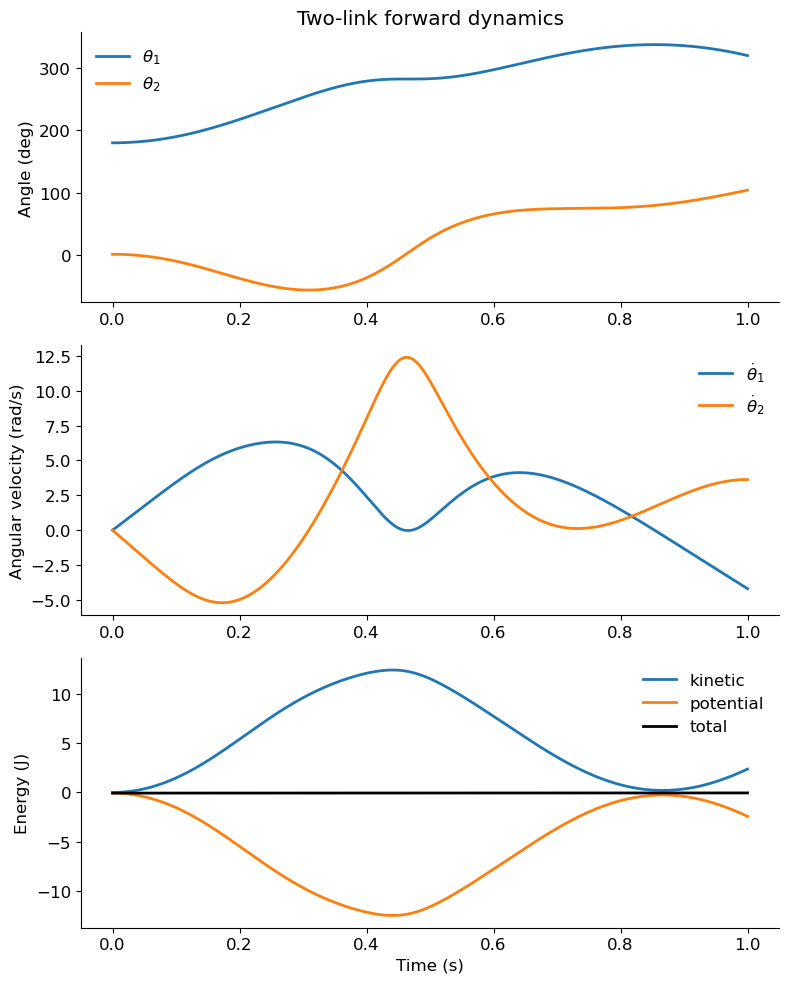

In [16]:
hand_trace = np.array([forward_kinematics_2link(theta, lengths=(two_link_params["l1"], two_link_params["l2"]))[1] for theta in theta_hist[::10]])

fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=False)

axes[0].plot(time, np.rad2deg(theta_hist[:, 0]), label=r"$\theta_1$", lw=2)
axes[0].plot(time, np.rad2deg(theta_hist[:, 1]), label=r"$\theta_2$", lw=2)
axes[0].set_ylabel("Angle (deg)")
axes[0].set_title("Two-link forward dynamics")
axes[0].legend(frameon=False)

axes[1].plot(time, dtheta_hist[:, 0], label=r"$\dot{\theta}_1$", lw=2)
axes[1].plot(time, dtheta_hist[:, 1], label=r"$\dot{\theta}_2$", lw=2)
axes[1].set_ylabel("Angular velocity (rad/s)")
axes[1].legend(frameon=False)

axes[2].plot(time, kinetic, label="kinetic", lw=2)
axes[2].plot(time, potential, label="potential", lw=2)
axes[2].plot(time, kinetic + potential, label="total", lw=2, color="black")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Energy (J)")
axes[2].legend(frameon=False)

plt.tight_layout()
plt.show()

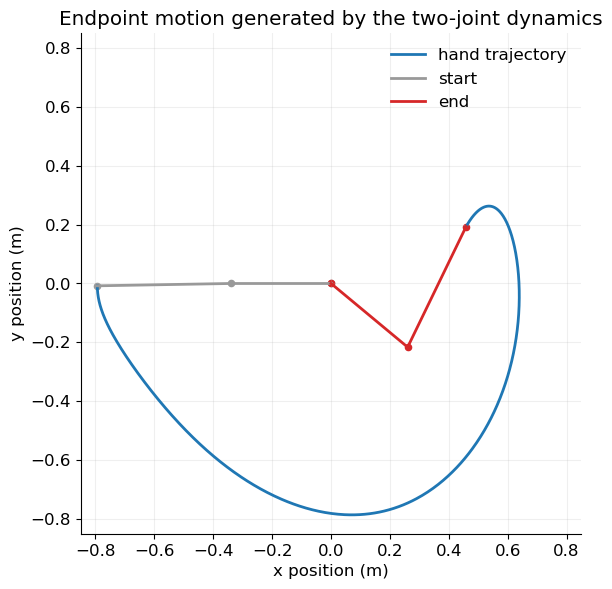

In [17]:
fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.plot(hand_trace[:, 0], hand_trace[:, 1], color="C0", lw=2, label="hand trajectory")
draw_two_link(ax, theta_hist[0], lengths=(two_link_params["l1"], two_link_params["l2"]), color="0.6", lw=2, label="start")
draw_two_link(ax, theta_hist[-1], lengths=(two_link_params["l1"], two_link_params["l2"]), color="C3", lw=2, label="end")
set_equal_axes(ax, lim=0.85)
ax.set_title("Endpoint motion generated by the two-joint dynamics")
ax.set_xlabel("x position (m)")
ax.set_ylabel("y position (m)")
ax.legend(frameon=False)
plt.show()